### Task 1: Designing a Heuristic for a Warehouse Robot

In [1]:
import math
import networkx as nx
import matplotlib.pyplot as plt


# 1. Coordinates of warehouse locations

locations = {
    "Receiving_Area": (0, 0),
    "Storage_A": (2, 1),
    "Storage_B": (1, 4),
    "Sorting_Area": (4, 2),
    "Inspection_Area": (5, 5),
    "Packing_Station": (7, 6)
}


# 2. Weighted warehouse graph

warehouse_graph = {
    "Receiving_Area": {
        "Storage_A": 2.2,
        "Storage_B": 4.1
    },

    "Storage_A": {
        "Sorting_Area": 2.2
    },

    "Storage_B": {
        "Inspection_Area": 5.0,
        "Sorting_Area": 6.0
    },

    "Sorting_Area": {
        "Inspection_Area": 3.2,
        "Packing_Station": 5.0
    },

    "Inspection_Area": {
        "Packing_Station": 2.2
    },

    "Packing_Station": {}
}


# 3. Euclidean heuristic


def heuristic(current, goal):
    return math.dist(locations[current], locations[goal])


# 4. Calculate heuristic values

goal = "Packing_Station"

print("Heuristic Values")
print("----------------")
print(f"{'Location':20s}{'h(n)':>10s}")

for location in locations:
    h = heuristic(location, goal)
    print(f"{location:20s}{h:10.3f}")

Heuristic Values
----------------
Location                  h(n)
Receiving_Area           9.220
Storage_A                7.071
Storage_B                6.325
Sorting_Area             5.000
Inspection_Area          2.236
Packing_Station          0.000


#### NetworkX visualization: Since Task 1 does not ask GBFS/A* to find a path, you are supposed highlight the actual minimum-cost path merely for visualization:

In [2]:
# 5. Create NetworkX graph

G = nx.DiGraph()

for node, neighbors in warehouse_graph.items():
    for neighbor, weight in neighbors.items():
        G.add_edge(node, neighbor, weight=weight)

# 6. Find minimum-cost path
## The primary function to find the shortest path in the Python networkx library 
### 1. Unweighted shortest path (ignores 'weight', finds fewest number of edges)
### 2. Weighted shortest path (minimizes the sum of the 'weight' attribute)
solution_path = nx.shortest_path( # reaturn the path e.g. A → B → C
    G,#pass the graph object
    source="Receiving_Area",
    target="Packing_Station",
    weight="weight"
)

solution_cost = nx.shortest_path_length( #return the numeric value
     G,#pass the graph object
        source="Receiving_Area",
        target="Packing_Station",
        weight="weight"
)

print("\nMinimum cost path:")
print(" -> ".join(solution_path))
print(f"Total cost: {solution_cost:.2f}")


Minimum cost path:
Receiving_Area -> Storage_A -> Sorting_Area -> Packing_Station
Total cost: 9.40


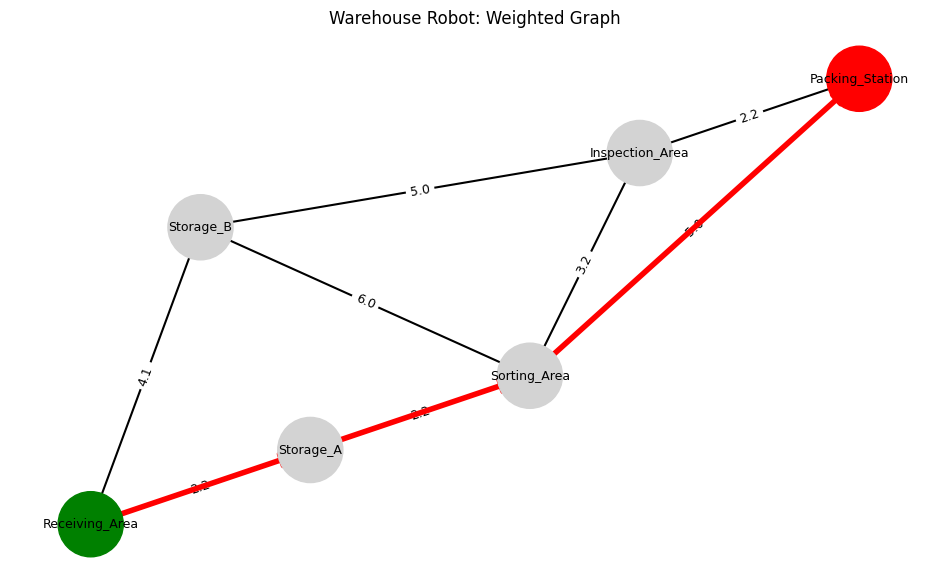

In [3]:
# 7. Visualize graph

pos = locations

plt.figure(figsize=(12, 7))

# write code to draw the graph with nodes, edges, and labels along with the highlighted solution path.
node_colors = [
    "green" if node == "Receiving_Area" else
    "red" if node == "Packing_Station" else
    "lightgray"
    for node in G.nodes()
]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2200)
nx.draw_networkx_labels(G, pos, font_size=9)
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="-|>", arrowsize=20, width=1.5)

edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

solution_edges = list(zip(solution_path[:-1], solution_path[1:]))
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=solution_edges,
    edge_color="red",
    width=4,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=22
)

plt.title("Warehouse Robot: Weighted Graph")
plt.axis("off")
plt.show()

In [4]:
# 8. Verify heuristic condition

print("\nHeuristic Condition Verification")
print("***********************************")

for node in warehouse_graph:

    for neighbor, cost in warehouse_graph[node].items():

        h_node = heuristic(node, goal)
        h_neighbor = heuristic(neighbor, goal)
        condition = h_node <= cost + h_neighbor

        print(
            f"{node} -> {neighbor}: "
            f"{h_node:.3f} <= {cost:.3f} + {h_neighbor:.3f} "
            f"= {cost + h_neighbor:.3f} : {condition}"
        )


Heuristic Condition Verification
***********************************
Receiving_Area -> Storage_A: 9.220 <= 2.200 + 7.071 = 9.271 : True
Receiving_Area -> Storage_B: 9.220 <= 4.100 + 6.325 = 10.425 : True
Storage_A -> Sorting_Area: 7.071 <= 2.200 + 5.000 = 7.200 : True
Storage_B -> Inspection_Area: 6.325 <= 5.000 + 2.236 = 7.236 : True
Storage_B -> Sorting_Area: 6.325 <= 6.000 + 5.000 = 11.000 : True
Sorting_Area -> Inspection_Area: 5.000 <= 3.200 + 2.236 = 5.436 : True
Sorting_Area -> Packing_Station: 5.000 <= 5.000 + 0.000 = 5.000 : True
Inspection_Area -> Packing_Station: 2.236 <= 2.200 + 0.000 = 2.200 : False


Euclidean distance is suitable because the warehouse locations have fixed 2D coordinates, so straight-line distance gives a direct estimate of the remaining distance to the Packing Station. It depends only on the current location and the goal and is inexpensive to compute. The consistency check is not satisfied for every edge: `Inspection_Area -> Packing_Station` fails because `2.236 > 2.200 + 0.000`.

### Task 2: Greedy Best-First Search for Airport Baggage Handling

In [5]:
import math
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# 1. Airport coordinates

locations = {
    "Baggage_Area": (0, 0),
    "Security": (2, 1),
    "Checkpoint": (1, 4),
    "Food_Court": (4, 2),
    "Terminal_Hall": (5, 5),
    "Departure_Gate": (8, 6)
}

# 2. Weighted graph


airport_graph = {
    "Baggage_Area": {
        "Security": 2.2,
        "Checkpoint": 4.1
    },

    "Security": {
        "Food_Court": 2.2
    },

    "Checkpoint": {
        "Terminal_Hall": 5.0
    },

    "Food_Court": {
        "Terminal_Hall": 3.2,
        "Departure_Gate": 6.0
    },

    "Terminal_Hall": {
        "Departure_Gate": 3.2
    },

    "Departure_Gate": {}
}

# 3. Euclidean heuristic


def heuristic(current, goal):

    return math.dist(locations[current], locations[goal])


# 4. GBFS


def greedy_best_first_search(start, goal, graph):

    # write code to implement the Greedy Best-First Search algorithm using a priority queue (min-heap) 
    # to explore nodes based on their heuristic values. Keep track of the path and expansion order.
    frontier = []
    heapq.heappush(frontier, (heuristic(start, goal), start))
    visited = set()
    came_from = {start: None}
    expansion_order = []

    while frontier:
        _, current = heapq.heappop(frontier)

        if current in visited:
            continue

        visited.add(current)
        expansion_order.append(current)

        if current == goal:
            break

        for neighbor in graph[current]:
            if neighbor not in visited and neighbor not in came_from:
                came_from[neighbor] = current
                heapq.heappush(frontier, (heuristic(neighbor, goal), neighbor))

    if goal not in came_from:
        return None, math.inf, expansion_order

    # Reconstruct path
    path = []
    current = goal
    while current is not None:
        path.append(current)
        current = came_from[current]
    path.reverse()

    # Calculate actual path cost
    total_cost = sum(graph[path[i]][path[i + 1]] for i in range(len(path) - 1))

    return path, total_cost, expansion_order


# 5. Run GBFS


# define the start state 
start = "Baggage_Area"
# define the goal state
goal = "Departure_Gate"

# call the greedy_best_first_search function with the start state, goal state, and airport_graph as arguments
path, total_cost, expansion_order = greedy_best_first_search(start, goal, airport_graph)

print("GBFS")
print("--------------------------------")
print("Expansion order:")
print(" -> ".join(expansion_order))

print("\nSolution path:")
print(" -> ".join(path))

print(f"\nTotal path cost: {total_cost:.2f}")
print("\nGBFS always expands the frontier node with the smallest h(n), so it follows the location that appears closest to the Departure Gate. From Baggage_Area, Checkpoint has a smaller heuristic than Security, then Terminal_Hall is closer than the remaining alternatives, so the search reaches Departure_Gate through that sequence.")

GBFS
--------------------------------
Expansion order:
Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate

Solution path:
Baggage_Area -> Checkpoint -> Terminal_Hall -> Departure_Gate

Total path cost: 12.30

GBFS always expands the frontier node with the smallest h(n), so it follows the location that appears closest to the Departure Gate. From Baggage_Area, Checkpoint has a smaller heuristic than Security, then Terminal_Hall is closer than the remaining alternatives, so the search reaches Departure_Gate through that sequence.


#### NetworkX visualization

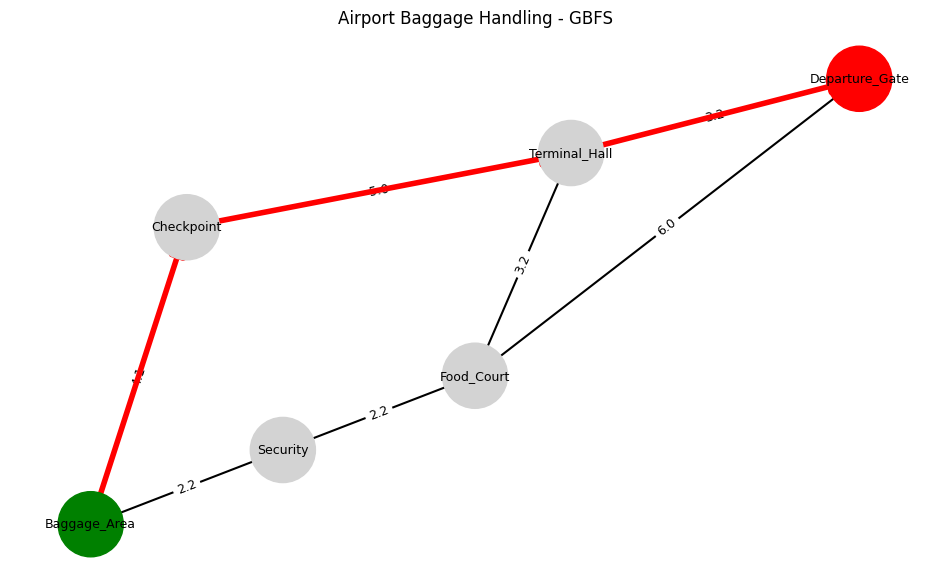

In [6]:
# 6. NetworkX visualization

G = nx.DiGraph()

for node, neighbors in airport_graph.items():
    for neighbor, weight in neighbors.items():
        G.add_edge(node, neighbor, weight=weight)


pos = locations

plt.figure(figsize=(12, 7))

# write code to draw the graph with nodes, edges, and labels along with the highlighted solution path.
node_colors = [
    "green" if node == start else
    "red" if node == goal else
    "lightgray"
    for node in G.nodes()
]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2200)
nx.draw_networkx_labels(G, pos, font_size=9)
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="-|>", arrowsize=20, width=1.5)

edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

solution_edges = list(zip(path[:-1], path[1:]))
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=solution_edges,
    edge_color="red",
    width=4,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=22
)

plt.title("Airport Baggage Handling - GBFS")
plt.axis("off")
plt.show()

### Task 3: A* Search for Emergency Supply Robot

In [7]:
import math
import heapq
import networkx as nx
import matplotlib.pyplot as plt


# 1. Hospital coordinates


locations = {
    "Pharmacy": (0, 0),
    "Main_Corridor": (2, 1),
    "Patient_Wing": (1, 4),
    "Nursing_Station": (4, 2),
    "Laboratory": (5, 5),
    "Emergency_Ward": (8, 6)
}


# 2. Hospital weighted graph


hospital_graph = {
    "Pharmacy": {
        "Main_Corridor": 2.2,
        "Patient_Wing": 4.1
    },

    "Main_Corridor": {
        "Nursing_Station": 2.2
    },

    "Patient_Wing": {
        "Laboratory": 5.0
    },

    "Nursing_Station": {
        "Laboratory": 3.2,
        "Emergency_Ward": 6.0
    },

    "Laboratory": {
        "Emergency_Ward": 3.2
    },

    "Emergency_Ward": {}
}

# 3. Euclidean heuristic


def heuristic(current, goal):

   return math.dist(locations[current], locations[goal])

# 4. Path reconstruction

def reconstruct_path(came_from, current):

    path = [current]
    while current in came_from:
        current = came_from[current]
        path.append(current)
    path.reverse()
    return path

# 5. A* Search
def a_star_search(start, goal, graph):
    # write code to implement the A* Search algorithm using a priority queue (min-heap) 
    # to explore nodes based on their f(n) = g(n) + h(n) values. Keep track of the path, expansion order, and g(n) costs.
    frontier = []
    g_cost = {start: 0.0}
    came_from = {}
    expansion_order = []

    heapq.heappush(frontier, (heuristic(start, goal), 0.0, start))

    while frontier:
        _, popped_g, current = heapq.heappop(frontier)

        if popped_g != g_cost.get(current, math.inf):
            continue

        expansion_order.append(current)

        if current == goal:
            path = reconstruct_path(came_from, current)
            return path, g_cost[current], expansion_order, g_cost

        for neighbor, edge_cost in graph[current].items():
            tentative_g = g_cost[current] + edge_cost

            if tentative_g < g_cost.get(neighbor, math.inf):
                g_cost[neighbor] = tentative_g
                came_from[neighbor] = current
                f = tentative_g + heuristic(neighbor, goal)
                heapq.heappush(frontier, (f, tentative_g, neighbor))

    return None, math.inf, expansion_order, g_cost

# 6. Run A*

# define the start state
start = "Pharmacy"
# define the goal state
goal = "Emergency_Ward"

# call the a_star_search function with the start state, goal state, and hospital_graph as arguments
path, total_cost, expansion_order, g_cost = a_star_search(start, goal, hospital_graph)

print("A* Search")
print("--------------------------------")

print("Expansion order:")
print(" -> ".join(expansion_order))

print("\nSolution path:")
print(" -> ".join(path))

print(f"\nTotal path cost: {total_cost:.2f}")

A* Search
--------------------------------
Expansion order:
Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward

Solution path:
Pharmacy -> Main_Corridor -> Nursing_Station -> Emergency_Ward

Total path cost: 10.40


#### g(n), h(n), f(n) table

In [8]:
# you may also replace it with dataframe it is completely your own choice

print("\nA* Node Information")
print("*********************")
print(
    f"{'Node':20s}" #'Node' → the text to print, 20 → use 20 spaces/characters of width, s → treat it as a string
    f"{'g(n)':>10s}"
    f"{'h(n)':>10s}"
    f"{'f(n)':>10s}"
)

for node in expansion_order:

    g = g_cost[node]
    h = heuristic(node, goal)
    f = g + h

    print(
        f"{node:20s}"
        f"{g:10.2f}"
        f"{h:10.2f}"
        f"{f:10.2f}"
    )


A* Node Information
*********************
Node                      g(n)      h(n)      f(n)
Pharmacy                  0.00     10.00     10.00
Main_Corridor             2.20      7.81     10.01
Nursing_Station           4.40      5.66     10.06
Emergency_Ward           10.40      0.00     10.40


#### NetworkX visualization

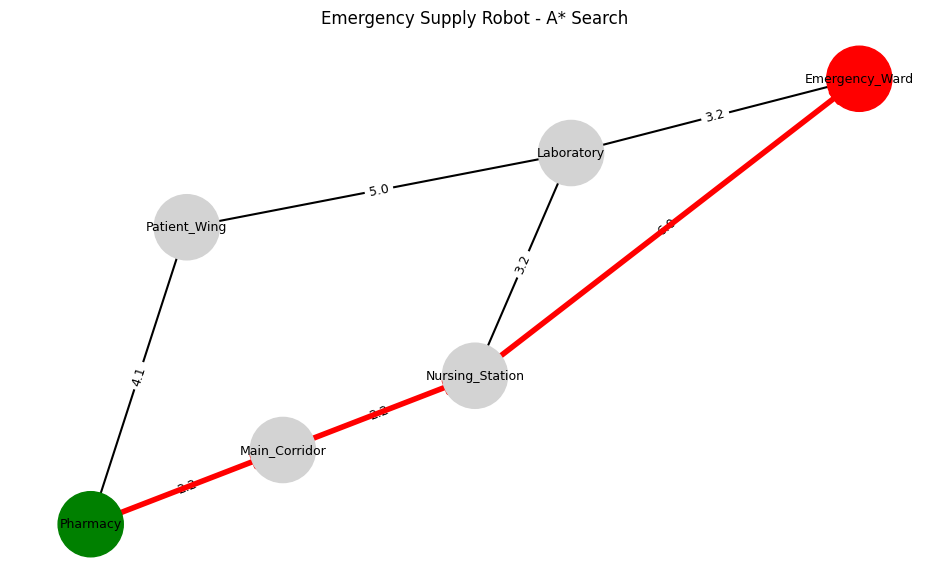

In [9]:
# 7. NetworkX visualization
G = nx.DiGraph()

for node, neighbors in hospital_graph.items():
    for neighbor, weight in neighbors.items():
        G.add_edge(node, neighbor, weight=weight)


pos = locations

plt.figure(figsize=(12, 7))

# write code to draw the graph with nodes, edges, and labels along with the highlighted solution path.
node_colors = [
    "green" if node == start else
    "red" if node == goal else
    "lightgray"
    for node in G.nodes()
]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2200)
nx.draw_networkx_labels(G, pos, font_size=9)
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="-|>", arrowsize=20, width=1.5)

edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

solution_edges = list(zip(path[:-1], path[1:]))
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=solution_edges,
    edge_color="red",
    width=4,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=22
)

plt.title("Emergency Supply Robot - A* Search")
plt.axis("off")
plt.show()

GBFS would primarily ask:

"Which node appears closest to the Emergency Ward?"

A* instead asks:

"Considering both the cost already travelled and the estimated remaining cost, which node has the lowest estimated total cost?"

Because A* includes g(n), it balances the cost already paid with the heuristic estimate, while GBFS ignores the travelled cost and follows only h(n). This makes A* less likely to commit to a route that looks close to the goal but is expensive to reach.

### Task 4: Weighted A* for Autonomous Delivery Drone

In [10]:
import math
import heapq
import pandas as pd

# 1. Location Coordinates

locations = {
    "Distribution_Center": (0, 0),
    "Zone_A": (2, 1),
    "Zone_B": (1, 4),
    "Zone_C": (4, 2),
    "Zone_D": (5, 5),
    "Customer_Building": (8, 6)
}

# 2. Weighted Graph

graph = {
    "Distribution_Center": {
        "Zone_A": 2.2,
        "Zone_B": 3.0
    },

    "Zone_A": {
        "Zone_C": 2.2
    },

    "Zone_B": {
        "Zone_D": 5.0
    },

    "Zone_C": {
        "Zone_D": 3.2,
        "Customer_Building": 6.0
    },

    "Zone_D": {
        "Customer_Building": 3.2
    },

    "Customer_Building": {}
}

# 3. Euclidean Heuristic

def heuristic(node, goal):

    return math.dist(locations[node], locations[goal])

# 4. Display Heuristic Values
goal = "Customer_Building"

heuristic_data = []

for node in locations:

    heuristic_data.append({
        "Node": node,
        "h(n)": round(heuristic(node, goal), 2)
    })

heuristic_df = pd.DataFrame(heuristic_data)

print("Heuristic Values:")
print(heuristic_df.to_string(index=False))

# 5. Weighted A* Search
# f(n) = g(n) + w * h(n)


def weighted_a_star(start, goal, graph, weight):
    # use same structure as A* search, but modify the f(n) calculation to include the weight parameter.
    frontier = []
    came_from = {}
    g_cost = {start: 0.0}
    expansion_order = []

    heapq.heappush(frontier, (weight * heuristic(start, goal), 0.0, start))

    while frontier:
        _, popped_g, current = heapq.heappop(frontier)

        if popped_g != g_cost.get(current, math.inf):
            continue

        expansion_order.append(current)

        if current == goal:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            path.reverse()
            return path, g_cost[goal], expansion_order

        for neighbor, edge_cost in graph[current].items():
            tentative_g = g_cost[current] + edge_cost

            if tentative_g < g_cost.get(neighbor, math.inf):
                g_cost[neighbor] = tentative_g
                came_from[neighbor] = current
                f = tentative_g + weight * heuristic(neighbor, goal)
                heapq.heappush(frontier, (f, tentative_g, neighbor))

    return None, math.inf, expansion_order

# 6. Run Weighted A* for All Required Weights
start = "Distribution_Center"
goal = "Customer_Building"

weights = [1, 1.5, 2, 3]

results = []

for w in weights:

    path, cost, expansion_order = weighted_a_star(
        start,
        goal,
        graph,
        w
    )

    results.append({
        "Weight": w,
        "Solution Path": " → ".join(path),
        "Total Cost": round(cost, 2),
        "Nodes Expanded": len(expansion_order),
        "Expansion Order": " → ".join(expansion_order)
    })


# 7. Display Results in dataframe
results_df = pd.DataFrame(results)
print("\nWeighted A* Results")
print(results_df.to_string(index=False))


# 8. Display Detailed Expansion Orders
print("\nDetailed Expansion Orders")
print("*************************")
for result in results:
    print(f"w = {result['Weight']}: {result['Expansion Order']}")

print("\nIncreasing w shifts more trust from the actual travelled cost g(n) to the heuristic h(n), so the search becomes more goal-directed. For w > 1, Weighted A* can return a costlier path because it may commit to nodes that look closer to the goal before fully accounting for the route cost. With w = 1 the method is normal A* and is optimal here, while w > 1 does not guarantee optimality.")


# ***
# Expected Main Results
# ***

# w = 1:
# Distribution_Center → Zone_A → Zone_C → Customer_Building
# Cost = 10.4
#
# w = 1.5:
# Distribution_Center → Zone_A → Zone_C → Customer_Building
# Cost = 10.4
#
# w = 2:
# Distribution_Center → Zone_B → Zone_D → Customer_Building
# Cost = 11.2
#
# w = 3:
# Distribution_Center → Zone_B → Zone_D → Customer_Building
# Cost = 11.2

Heuristic Values:
               Node  h(n)
Distribution_Center 10.00
             Zone_A  7.81
             Zone_B  7.28
             Zone_C  5.66
             Zone_D  3.16
  Customer_Building  0.00

Weighted A* Results
 Weight                                             Solution Path  Total Cost  Nodes Expanded                                                    Expansion Order
    1.0 Distribution_Center → Zone_A → Zone_C → Customer_Building        10.4               5 Distribution_Center → Zone_A → Zone_C → Zone_B → Customer_Building
    1.5 Distribution_Center → Zone_A → Zone_C → Customer_Building        10.4               4          Distribution_Center → Zone_A → Zone_C → Customer_Building
    2.0 Distribution_Center → Zone_B → Zone_D → Customer_Building        11.2               4          Distribution_Center → Zone_B → Zone_D → Customer_Building
    3.0 Distribution_Center → Zone_B → Zone_D → Customer_Building        11.2               4          Distribution_Center → Zone_B → Z

#### NetworkX visualization

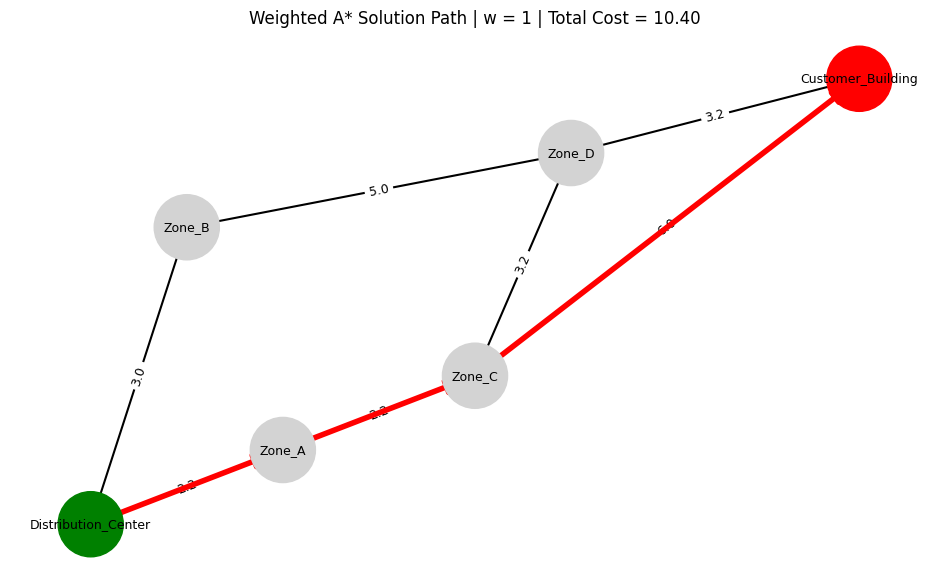

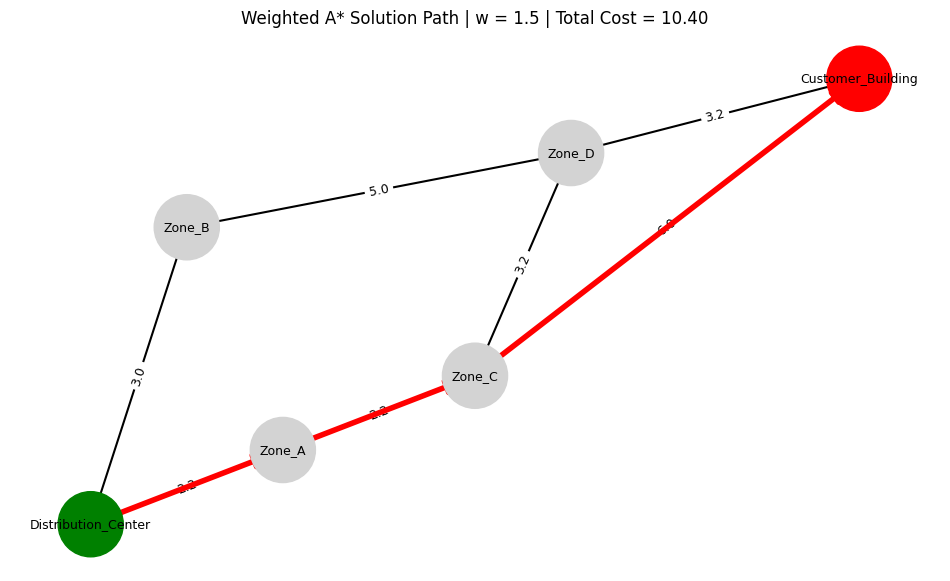

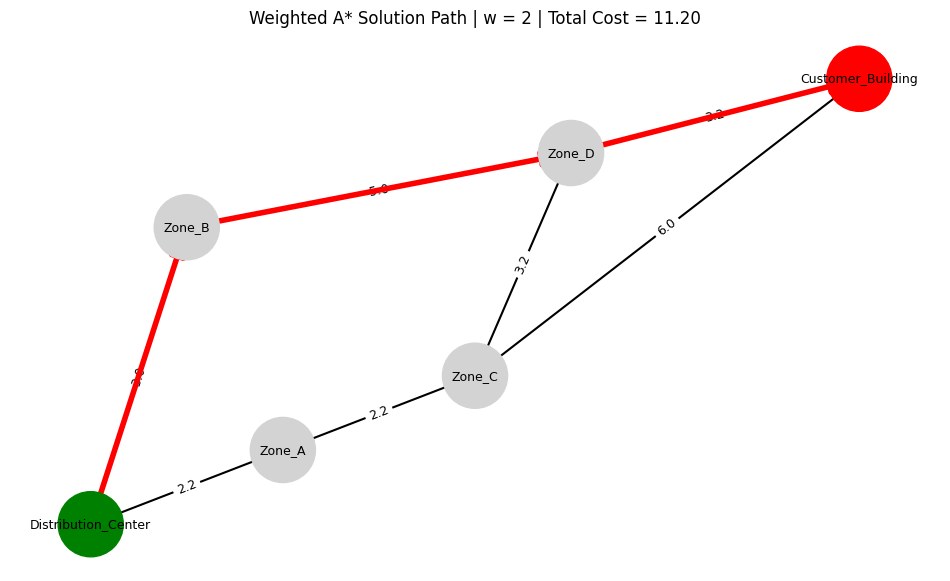

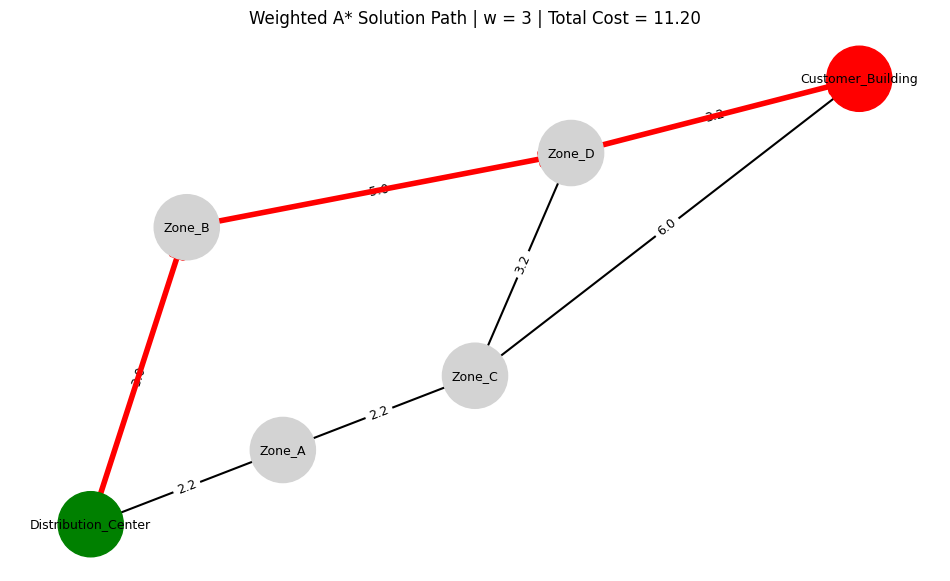

In [11]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Create NetworkX Graph

G = nx.DiGraph()

# Add nodes with their coordinates
for node, position in locations.items():

    G.add_node(
        node,
        pos=position
    )


# Add weighted edges
for node, neighbors in graph.items():

    for neighbor, cost in neighbors.items():

        G.add_edge(node, neighbor, weight=cost)

# 2. Node Positions
pos = locations

# 3. Visualize Weighted A* Result for Each Weight

for w in weights:

    # Run Weighted A*
    path, cost, expansion_order = weighted_a_star(start, goal, graph, w)

    plt.figure(figsize=(12, 7))

    node_colors = [
        "green" if node == start else
        "red" if node == goal else
        "lightgray"
        for node in G.nodes()
    ]

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2200)
    nx.draw_networkx_labels(G, pos, font_size=9)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="-|>", arrowsize=20, width=1.5)

    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

    solution_edges = list(zip(path[:-1], path[1:]))
    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=solution_edges,
        edge_color="red",
        width=4,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=22
    )

    plt.title(
        f"Weighted A* Solution Path | w = {w} | "
        f"Total Cost = {cost:.2f}"
    )

    plt.axis("off")

    plt.show()

#### Expansion order

This means:

In what order did the search algorithm remove/select nodes from the frontier and process them?

For example:

Expanded:
S → A → B → C → D → G

The algorithm may explore some nodes that are ultimately not part of the final route.

#### Solution path

This means:

Which nodes form the final route from start to goal?

For example:

Solution:
S → A → C → G

Here:

Expansion order:  S → A → B → C → D → G
Solution path:    S → A → C → G